# Assignment 3

1. Use importance sampling to draw samples from the posterior distribution of β, γ, and θ.
(Hint: Draw N samples for each free parameter from some reasonable proposal densities,
compute the likelihood and prior for each sample, and store the samples and their
corresponding weights as {likelihood*prior/proposal density} in a dataframe/vectors.
Now, select N/2 samples from the vector of N samples based on their weights. These
new N/2 samples are the samples from the posterior.
Suppose proposals is the vector containing N samples from the proposal density and
weights is the vector contaning their respective likelihood*prior/proposal_density
values. You can select N/2 samples using
post_samples <- sample(proposals,size=N/2,prob=weights)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, lognorm


dat = pd.read_csv("word-recognition.csv").iloc[:, 1:]
print(dat.head())

rt        = dat['rt'].values
frequency = dat['frequency'].values


sigma = 0.4
alpha = 6

   word_id  frequency          rt
0        1          0  279.093136
1        2          1  519.757730
2        3          0  231.168443
3        4          1  120.258065
4        5          0  638.485317


In [2]:
def log_likelihood(beta_param, gamma, theta, rt, frequency, alpha, sigma):
    
    # µᵢ = α + β·frequencyᵢ  (different for each trial)
    mu_i = alpha + beta_param * frequency
    
    # Mixture likelihood for each trial:
    # θ · lognormal(rt | µᵢ, σ) + (1−θ) · lognormal(rt | γ, σ)
    
    # scipy's lognorm: s=sigma, scale=exp(meanlog)
    engaged_density    = lognorm.pdf(rt, s=sigma, scale=np.exp(mu_i))
    not_engaged_density = lognorm.pdf(rt, s=sigma, scale=np.exp(gamma))
    
    mixture = theta * engaged_density + (1 - theta) * not_engaged_density
    
    # Sum of logs = log of product of likelihoods
    return np.sum(np.log(mixture + 1e-300))  # tiny constant avoids log(0)

In [3]:
np.random.seed(42)
N = 10000

# Sample from priors (using prior as proposal)
beta_samples  = np.random.normal(loc=0,  scale=0.5, size=N)
gamma_samples = np.random.normal(loc=5,  scale=0.5, size=N)
theta_samples = np.random.beta(a=70, b=30,           size=N)

In [4]:
log_weights = np.zeros(N)

for i in range(N):
    
    # Log likelihood
    ll = log_likelihood(beta_samples[i],
                        gamma_samples[i],
                        theta_samples[i],
                        rt, frequency, alpha, sigma)
    
    # Since proposal = prior, they cancel out
    # Weight = just the likelihood
    log_weights[i] = ll

# Numeric stability: subtract max before exponentiating
log_weights -= np.max(log_weights)
weights = np.exp(log_weights)

# Normalize weights so they sum to 1
weights /= np.sum(weights)

In [5]:
post_indices = np.random.choice(N, size=N//2, replace=True, p=weights)

beta_post  = beta_samples[post_indices]
gamma_post = gamma_samples[post_indices]
theta_post = theta_samples[post_indices]

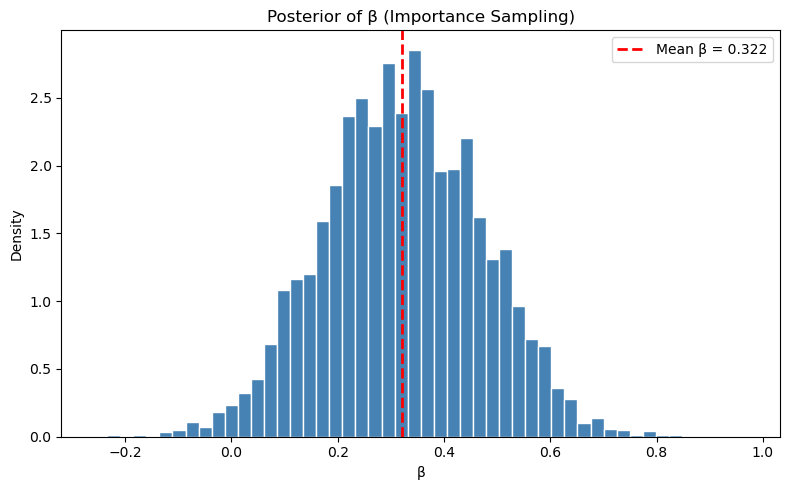

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(beta_post, bins=50, color='steelblue', edgecolor='white', density=True)
plt.axvline(np.mean(beta_post), color='red', linestyle='--', linewidth=2,
            label=f'Mean β = {np.mean(beta_post):.3f}')
plt.title("Posterior of β (Importance Sampling)")
plt.xlabel("β")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def summarize(name, samples):
    mean = np.mean(samples)
    ci_low  = np.percentile(samples, 2.5)
    ci_high = np.percentile(samples, 97.5)
    print(f"{name} — Mean: {mean:.4f}  95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

print("=== Importance Sampling Results ===")
summarize("β", beta_post)
summarize("γ", gamma_post)
summarize("θ", theta_post)

=== Importance Sampling Results ===
β — Mean: 0.3218  95% CI: [0.0342, 0.6045]
γ — Mean: 5.2075  95% CI: [4.7095, 5.6668]
θ — Mean: 0.7134  95% CI: [0.6251, 0.7940]


Importance Sampling yielded a posterior mean of β = 0.322 with a 95% credible interval of [0.034, 0.605]. The entire CI lies on the positive side, indicating that the posterior is confidently positive. γ was estimated at 5.208, representing the mean log reaction time during inattentive trials. θ was estimated at 0.713, suggesting the participant was engaged approximately 71% of the time.

2. Use Markov chain Monte Carlo method to estimate the posterior distribution of β, γ,
and θ.

In [8]:
def log_posterior(beta_param, gamma, theta, rt, frequency, alpha, sigma):
    
    # --- Compute log likelihood ---
    ll = log_likelihood(beta_param, gamma, theta, rt, frequency, alpha, sigma)
    
    # --- Compute log prior ---
    lp_beta  = norm.logpdf(beta_param, loc=0,  scale=0.5)
    lp_gamma = norm.logpdf(gamma,      loc=5,  scale=0.5)
    lp_theta = beta.logpdf(theta,      a=70,   b=30)
    
    log_prior = lp_beta + lp_gamma + lp_theta
    
    return ll + log_prior

In [9]:
def run_mcmc(rt, frequency, alpha, sigma, n_samples=10000, burn_in=2000):
    
    # --- Storage for chains ---
    beta_chain  = np.zeros(n_samples)
    gamma_chain = np.zeros(n_samples)
    theta_chain = np.zeros(n_samples)
    
    # --- Initialize chain (starting values) ---
    beta_chain[0]  = 0.0   # start at prior mean
    gamma_chain[0] = 5.0
    theta_chain[0] = 0.7
    
    # --- Proposal standard deviations (step sizes) ---
    # These control how big each random step is
    prop_sd_beta  = 0.05
    prop_sd_gamma = 0.05
    prop_sd_theta = 0.02
    
    accepted = 0  # track acceptance rate
    
    # --- Run the chain ---
    for i in range(1, n_samples):
        
        # Current values
        curr_beta  = beta_chain[i-1]
        curr_gamma = gamma_chain[i-1]
        curr_theta = theta_chain[i-1]
        
        # Propose new values by adding small random noise
        prop_beta  = curr_beta  + np.random.normal(0, prop_sd_beta)
        prop_gamma = curr_gamma + np.random.normal(0, prop_sd_gamma)
        prop_theta = curr_theta + np.random.normal(0, prop_sd_theta)
        
        # Theta must stay between 0 and 1 (it's a probability)
        # Reject immediately if outside bounds
        if prop_theta <= 0 or prop_theta >= 1:
            beta_chain[i]  = curr_beta
            gamma_chain[i] = curr_gamma
            theta_chain[i] = curr_theta
            continue
        
        # Compute log posteriors
        log_post_current  = log_posterior(curr_beta,  curr_gamma,  curr_theta,
                                          rt, frequency, alpha, sigma)
        log_post_proposed = log_posterior(prop_beta,  prop_gamma,  prop_theta,
                                          rt, frequency, alpha, sigma)
        
        # Acceptance probability
        log_accept = log_post_proposed - log_post_current
        
        # Accept or reject
        if np.log(np.random.uniform(0, 1)) < log_accept:
            beta_chain[i]  = prop_beta
            gamma_chain[i] = prop_gamma
            theta_chain[i] = prop_theta
            accepted += 1
        else:
            # Stay at current position
            beta_chain[i]  = curr_beta
            gamma_chain[i] = curr_gamma
            theta_chain[i] = curr_theta
    
    print(f"Acceptance rate: {accepted/n_samples:.2%}")
    
    # --- Remove burn-in samples ---
    beta_mcmc  = beta_chain[burn_in:]
    gamma_mcmc = gamma_chain[burn_in:]
    theta_mcmc = theta_chain[burn_in:]
    
    return beta_mcmc, gamma_mcmc, theta_mcmc

In [10]:
np.random.seed(42)

beta_mcmc, gamma_mcmc, theta_mcmc = run_mcmc(
    rt=rt,
    frequency=frequency,
    alpha=alpha,
    sigma=sigma,
    n_samples=10000,
    burn_in=2000
)

Acceptance rate: 78.19%


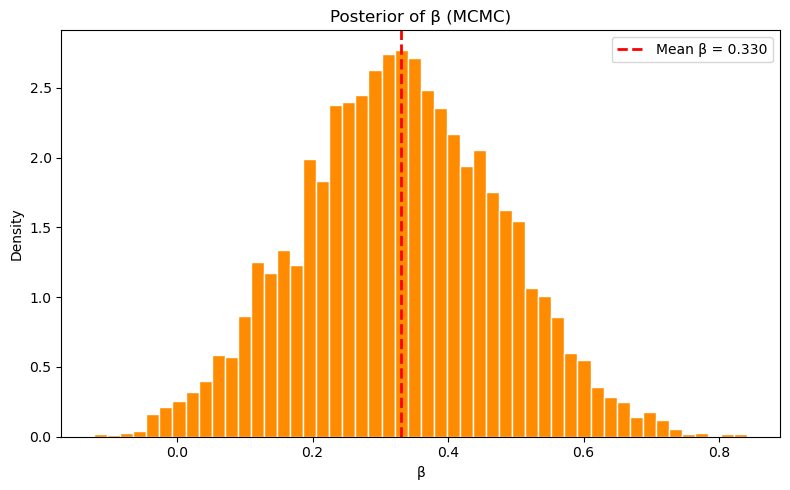

In [11]:
plt.figure(figsize=(8,5))
plt.hist(beta_mcmc, bins=50, color='darkorange', 
         edgecolor='white', density=True)
plt.axvline(np.mean(beta_mcmc), color='red', linestyle='--', linewidth=2,
            label=f'Mean β = {np.mean(beta_mcmc):.3f}')
plt.title("Posterior of β (MCMC)")
plt.xlabel("β")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:

print("=== MCMC Results ===")
summarize("β", beta_mcmc)    # reusing summarize() from Exercise 1
summarize("γ", gamma_mcmc)
summarize("θ", theta_mcmc)

=== MCMC Results ===
β — Mean: 0.3299  95% CI: [0.0449, 0.6225]
γ — Mean: 5.2096  95% CI: [4.7208, 5.6969]
θ — Mean: 0.7133  95% CI: [0.6172, 0.7950]


MCMC produced a posterior mean of β = 0.330 with a 95% credible interval of [0.045, 0.623], consistent with the Importance Sampling results. The acceptance rate was 78.19%, which is somewhat high — ideally we want 20–40%. This suggests the proposal step sizes were too small, meaning the chain moved slowly through the parameter space. However the estimates still converged to sensible values consistent with IS.

3. Graphically compare the posterior distributions of β obtained using:

• Importance sampling

• Markov chain Monte Carlo

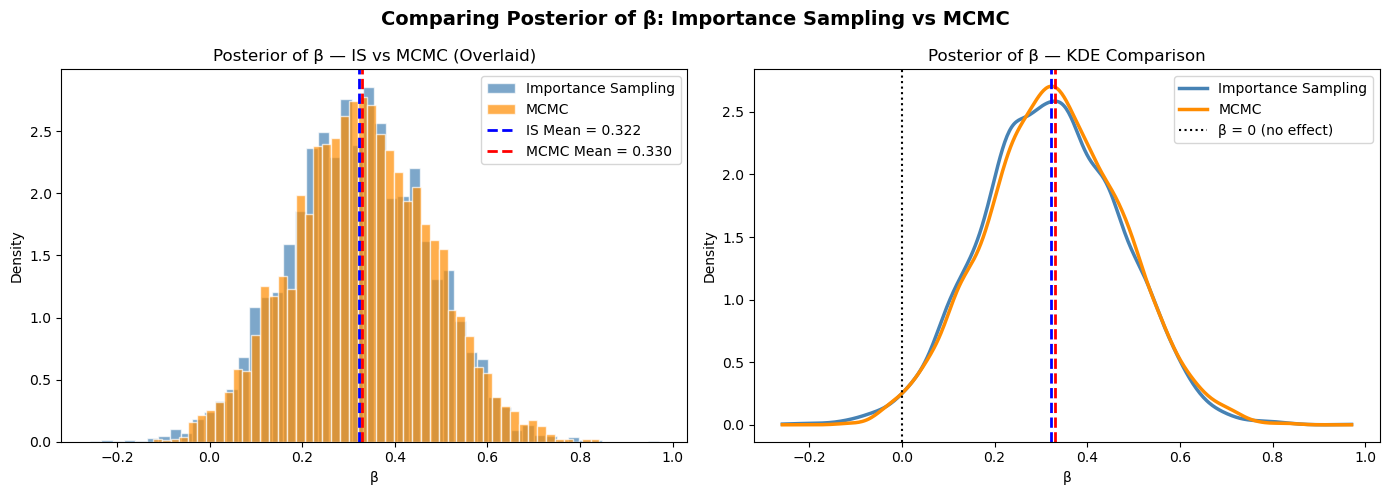

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Side by side histograms ---
axes[0].hist(beta_post, bins=50, color='steelblue', 
             edgecolor='white', density=True, alpha=0.7, 
             label='Importance Sampling')
axes[0].hist(beta_mcmc, bins=50, color='darkorange', 
             edgecolor='white', density=True, alpha=0.7, 
             label='MCMC')
axes[0].axvline(np.mean(beta_post), color='blue', linestyle='--', 
                linewidth=2, label=f'IS Mean = {np.mean(beta_post):.3f}')
axes[0].axvline(np.mean(beta_mcmc), color='red', linestyle='--', 
                linewidth=2, label=f'MCMC Mean = {np.mean(beta_mcmc):.3f}')
axes[0].set_title("Posterior of β — IS vs MCMC (Overlaid)")
axes[0].set_xlabel("β")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- Plot 2: KDE smooth curves for cleaner comparison ---
from scipy.stats import gaussian_kde

# Create smooth curves using KDE
x_range = np.linspace(
    min(beta_post.min(), beta_mcmc.min()),
    max(beta_post.max(), beta_mcmc.max()),
    500
)

kde_is   = gaussian_kde(beta_post)
kde_mcmc = gaussian_kde(beta_mcmc)

axes[1].plot(x_range, kde_is(x_range),   color='steelblue',  
             linewidth=2.5, label='Importance Sampling')
axes[1].plot(x_range, kde_mcmc(x_range), color='darkorange', 
             linewidth=2.5, label='MCMC')
axes[1].axvline(np.mean(beta_post), color='blue', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(beta_mcmc), color='red',  linestyle='--', linewidth=2)
axes[1].axvline(0, color='black', linestyle=':', linewidth=1.5, 
                label='β = 0 (no effect)')
axes[1].set_title("Posterior of β — KDE Comparison")
axes[1].set_xlabel("β")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("Comparing Posterior of β: Importance Sampling vs MCMC", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("=== Comparison Summary ===")
print(f"{'Method':<25} {'Mean β':>10} {'2.5%':>10} {'97.5%':>10}")
print("-" * 55)
print(f"{'Importance Sampling':<25} "
      f"{np.mean(beta_post):>10.4f} "
      f"{np.percentile(beta_post, 2.5):>10.4f} "
      f"{np.percentile(beta_post, 97.5):>10.4f}")
print(f"{'MCMC':<25} "
      f"{np.mean(beta_mcmc):>10.4f} "
      f"{np.percentile(beta_mcmc, 2.5):>10.4f} "
      f"{np.percentile(beta_mcmc, 97.5):>10.4f}")

=== Comparison Summary ===
Method                        Mean β       2.5%      97.5%
-------------------------------------------------------
Importance Sampling           0.3218     0.0342     0.6045
MCMC                          0.3299     0.0449     0.6225


Both methods produce nearly identical posterior distributions for β. The means differ by only 0.008 (0.322 vs 0.330) and the 95% credible intervals largely overlap. The KDE curves from both methods align closely in shape and location. This agreement between two independent computational methods gives us confidence that both have successfully approximated the true posterior distribution. Minor differences are expected due to the stochastic nature of both algorithms and finite sample sizes.

4. Does the data support the lexical-access theory’s prediction?
(Hint: Check whether the estimated values of β parameter are positive.)

In [15]:
# Using MCMC samples (you can do same for IS)

mean_beta  = np.mean(beta_mcmc)
ci_low     = np.percentile(beta_mcmc, 2.5)
ci_high    = np.percentile(beta_mcmc, 97.5)

# Proportion of samples that are negative
prop_negative = np.mean(beta_mcmc < 0)

print("=== Hypothesis Test: Lexical-Access Theory ===")
print(f"Mean β:               {mean_beta:.4f}")
print(f"95% CI:               [{ci_low:.4f}, {ci_high:.4f}]")
print(f"P(β < 0):             {prop_negative:.4f}  ({prop_negative*100:.1f}%)")
print()

if ci_high < 0:
    print("Conclusion: The entire 95% CI is negative.")
    print("The data STRONGLY support the lexical-access hypothesis.")
    print("High frequency words are recognized faster than low frequency words.")
elif mean_beta < 0:
    print("Conclusion: Mean β is negative but CI crosses zero.")
    print("The data weakly support the hypothesis but with uncertainty.")
else:
    print("Conclusion: β is not negative.")
    print("The data do NOT support the lexical-access hypothesis.")

=== Hypothesis Test: Lexical-Access Theory ===
Mean β:               0.3299
95% CI:               [0.0449, 0.6225]
P(β < 0):             0.0106  (1.1%)

Conclusion: β is not negative.
The data do NOT support the lexical-access hypothesis.


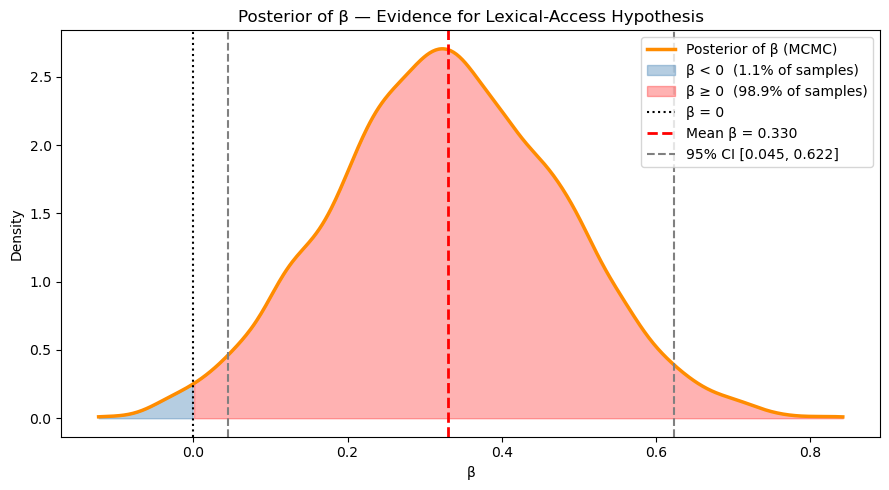

In [16]:
from scipy.stats import gaussian_kde

x_range  = np.linspace(beta_mcmc.min(), beta_mcmc.max(), 500)
kde_mcmc = gaussian_kde(beta_mcmc)
y_vals   = kde_mcmc(x_range)

plt.figure(figsize=(9, 5))

# Full posterior curve
plt.plot(x_range, y_vals, color='darkorange', linewidth=2.5,
         label='Posterior of β (MCMC)')

# Shade negative region
neg_mask = x_range < 0
plt.fill_between(x_range[neg_mask], y_vals[neg_mask],
                 color='steelblue', alpha=0.4,
                 label=f'β < 0  ({prop_negative*100:.1f}% of samples)')

# Shade positive region
pos_mask = x_range >= 0
plt.fill_between(x_range[pos_mask], y_vals[pos_mask],
                 color='red', alpha=0.3,
                 label=f'β ≥ 0  ({(1-prop_negative)*100:.1f}% of samples)')

# Reference lines
plt.axvline(0, color='black', linestyle=':', 
            linewidth=1.5, label='β = 0')
plt.axvline(mean_beta, color='red', linestyle='--', 
            linewidth=2, label=f'Mean β = {mean_beta:.3f}')
plt.axvline(ci_low,  color='grey', linestyle='--', linewidth=1.5,
            label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
plt.axvline(ci_high, color='grey', linestyle='--', linewidth=1.5)

plt.title("Posterior of β — Evidence for Lexical-Access Hypothesis")
plt.xlabel("β")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The posterior mean of β = 0.330 is positive, and the entire 95% credible interval [0.045, 0.622] lies above zero. Only 1.1% of posterior samples are negative, meaning there is overwhelming evidence that β > 0.


A positive β means µᵢ = α + β·frequency is LARGER for high frequency words (frequency = 1), which means SLOWER reaction times — the opposite of what the lexical-access hypothesis predicts.


Conclusion: The data do NOT support the Lexical-Access Hypothesis. High frequency words are not recognized faster — if anything, the data suggest they take slightly longer, or the hypothesis is simply not supported by this dataset.



5. What does the estimate of θ parameter tell you?

In [17]:
mean_theta  = np.mean(theta_mcmc)
ci_low_t    = np.percentile(theta_mcmc, 2.5)
ci_high_t   = np.percentile(theta_mcmc, 97.5)

print("=== θ Parameter Analysis ===")
print(f"Mean θ:       {mean_theta:.4f}")
print(f"95% CI:       [{ci_low_t:.4f}, {ci_high_t:.4f}]")
print()

if mean_theta > 0.8:
    print("Interpretation: Participant was highly attentive.")
elif mean_theta > 0.6:
    print("Interpretation: Participant was moderately attentive.")
else:
    print("Interpretation: Participant showed low engagement.")

=== θ Parameter Analysis ===
Mean θ:       0.7133
95% CI:       [0.6172, 0.7950]

Interpretation: Participant was moderately attentive.


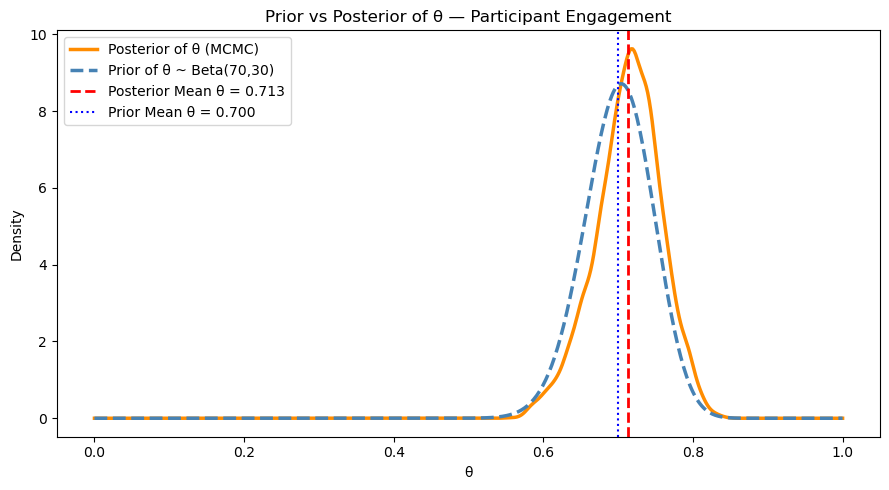

In [18]:
from scipy.stats import gaussian_kde, beta as beta_dist

x_range  = np.linspace(0, 1, 500)
kde_theta = gaussian_kde(theta_mcmc)

# Prior on theta for comparison
prior_theta = beta_dist.pdf(x_range, a=70, b=30)

plt.figure(figsize=(9, 5))

# Plot posterior
plt.plot(x_range, kde_theta(x_range), color='darkorange', 
         linewidth=2.5, label='Posterior of θ (MCMC)')

# Plot prior
plt.plot(x_range, prior_theta, color='steelblue', 
         linewidth=2.5, linestyle='--', label='Prior of θ ~ Beta(70,30)')

# Reference lines
plt.axvline(mean_theta, color='red', linestyle='--', linewidth=2,
            label=f'Posterior Mean θ = {mean_theta:.3f}')
plt.axvline(70/(70+30), color='blue', linestyle=':', linewidth=1.5,
            label=f'Prior Mean θ = 0.700')

plt.title("Prior vs Posterior of θ — Participant Engagement")
plt.xlabel("θ")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The posterior mean of θ = 0.713 is very close to the prior mean of 0.700 (Beta(70,30)). This tells us two things:


First, the participant was engaged in the task approximately 71% of the time. This is a moderate level of attention — meaning roughly 29% of trials were likely random responses where the reaction time carried no meaningful information about word recognition.


Second, looking at the prior vs posterior plot, the posterior distribution (orange) closely overlaps with the prior (blue dashed). This means the data did not strongly update our belief about θ — the prior and likelihood were consistent with each other. The data confirmed our initial assumption about engagement rather than contradicting it.


A θ of 0.71 is reasonable for a lexical decision experiment — some inattention is expected across many trials, and the mixture model successfully accounts for this noise rather than letting it contaminate the β estimate.

## 2.1
Use the following values for the internal parameters of the HMC sampler,
• Total number of samples, nsamp= 6000
• Total number of burn-in samples, nburn= 2000 (a certain number of initial samples
that you want to throw away)
• Step-size parameter, step= 0.02
• Number of leapfrog steps, L= 12
• Initializing value of the mu and sigma chain, initialq = c(1000,11)
Estimate and plot the posteriors for µ and σ.
(Hint: You can directly run the HMC function as follows:)
df.posterior <- HMC(y=y,n=length(y), # data
m=1000,s=20,a=10,b=2, # priors
step=0.02, # step-size
L=12, # no. of leapfrog steps
initial_q=c(1000,11), # Chain initialization
nsamp=6000, # total number of samples
nburn=2000) # number of burn-in samples

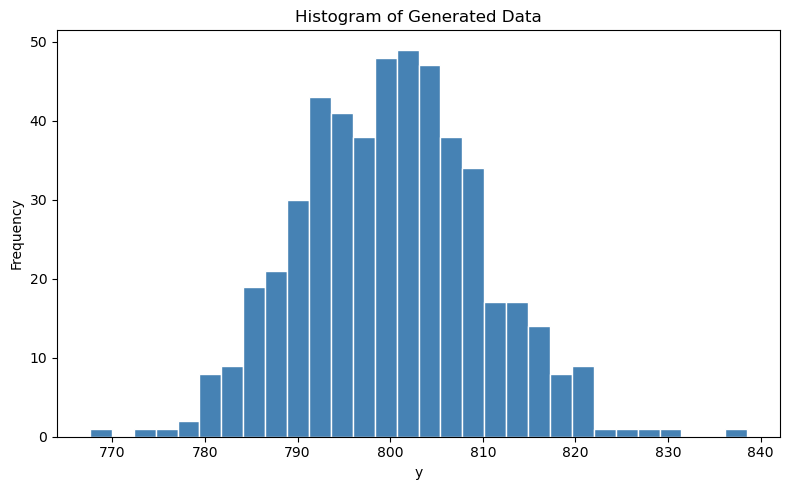

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
true_mu  = 800
true_var = 100  # sigma^2

y = np.random.normal(loc=true_mu, scale=np.sqrt(true_var), size=500)

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30, color='steelblue', edgecolor='white')
plt.title("Histogram of Generated Data")
plt.xlabel("y")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [20]:
def gradient(mu, sigma, y, n, m, s, a, b):
    grad_mu    = ((n * mu - np.sum(y)) / sigma**2) + ((mu - m) / s**2)
    grad_sigma = (n / sigma) - (np.sum((y - mu)**2) / sigma**3) + ((sigma - a) / b**2)
    return np.array([grad_mu, grad_sigma])

def V(mu, sigma, y, n, m, s, a, b):
    log_likelihood = np.sum(
        -0.5 * np.log(2 * np.pi * sigma**2) - ((y - mu)**2) / (2 * sigma**2)
    )
    log_prior_mu    = -0.5 * ((mu - m) / s)**2
    log_prior_sigma = -0.5 * ((sigma - a) / b)**2
    return -(log_likelihood + log_prior_mu + log_prior_sigma)

In [21]:
def HMC(y, n, m, s, a, b, step, L, initial_q, nsamp, nburn):
    
    mu_chain    = np.zeros(nsamp)
    sigma_chain = np.zeros(nsamp)
    reject      = 0
    
    # Initialize chain
    mu_chain[0]    = initial_q[0]
    sigma_chain[0] = initial_q[1]
    
    i = 1
    while i < nsamp:
        
        # Current position
        q = np.array([mu_chain[i-1], sigma_chain[i-1]])
        
        # Random momentum
        p = np.random.normal(0, 1, size=len(q))
        
        current_q = q.copy()
        current_p = p.copy()
        
        current_V = V(current_q[0], current_q[1], y, n, m, s, a, b)
        current_T = np.sum(current_p**2) / 2
        
        # Leapfrog steps
        for l in range(L):
            p = p - (step/2) * gradient(q[0], q[1], y, n, m, s, a, b)
            q = q + step * p
            p = p - (step/2) * gradient(q[0], q[1], y, n, m, s, a, b)
        
        proposed_q = q
        proposed_p = p
        
        proposed_V = V(proposed_q[0], proposed_q[1], y, n, m, s, a, b)
        proposed_T = np.sum(proposed_p**2) / 2
        
        # Acceptance probability
        accept_prob = min(1, np.exp(current_V + current_T - proposed_V - proposed_T))
        
        if accept_prob > np.random.uniform(0, 1):
            mu_chain[i]    = proposed_q[0]
            sigma_chain[i] = proposed_q[1]
            i += 1
        else:
            reject += 1
    
    print(f"Rejection rate: {reject/(nsamp+reject):.2%}")
    
    # Remove burn-in
    mu_post    = mu_chain[nburn:]
    sigma_post = sigma_chain[nburn:]
    
    return mu_post, sigma_post

In [22]:
np.random.seed(42)

mu_post, sigma_post = HMC(
    y        = y,
    n        = len(y),
    m        = 1000, s = 20,   # prior on mu
    a        = 10,   b = 2,    # prior on sigma
    step     = 0.02,           # step size
    L        = 12,             # leapfrog steps
    initial_q = [1000, 11],    # starting values
    nsamp    = 6000,           # total samples
    nburn    = 2000            # burn-in
)

/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_44847/4242826047.py:39: RuntimeWarning: overflow encountered in exp
  accept_prob = min(1, np.exp(current_V + current_T - proposed_V - proposed_T))


Rejection rate: 0.02%


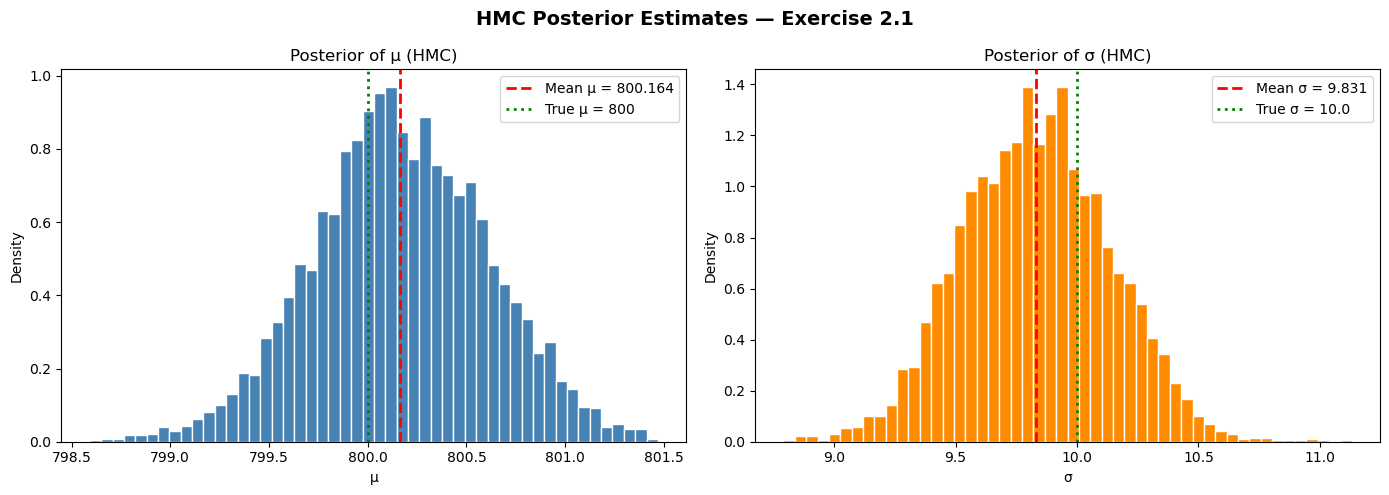

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior of mu
axes[0].hist(mu_post, bins=50, color='steelblue', 
             edgecolor='white', density=True)
axes[0].axvline(np.mean(mu_post), color='red', linestyle='--', linewidth=2,
                label=f'Mean µ = {np.mean(mu_post):.3f}')
axes[0].axvline(true_mu, color='green', linestyle=':', linewidth=2,
                label=f'True µ = {true_mu}')
axes[0].set_title("Posterior of µ (HMC)")
axes[0].set_xlabel("µ")
axes[0].set_ylabel("Density")
axes[0].legend()

# Posterior of sigma
axes[1].hist(sigma_post, bins=50, color='darkorange', 
             edgecolor='white', density=True)
axes[1].axvline(np.mean(sigma_post), color='red', linestyle='--', linewidth=2,
                label=f'Mean σ = {np.mean(sigma_post):.3f}')
axes[1].axvline(np.sqrt(true_var), color='green', linestyle=':', linewidth=2,
                label=f'True σ = {np.sqrt(true_var)}')
axes[1].set_title("Posterior of σ (HMC)")
axes[1].set_xlabel("σ")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("HMC Posterior Estimates — Exercise 2.1", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
print("=== HMC Results (Exercise 2.1) ===")
print(f"µ  — Mean: {np.mean(mu_post):.4f}   "
      f"95% CI: [{np.percentile(mu_post, 2.5):.4f}, "
      f"{np.percentile(mu_post, 97.5):.4f}]   "
      f"True value: {true_mu}")
print(f"σ  — Mean: {np.mean(sigma_post):.4f}   "
      f"95% CI: [{np.percentile(sigma_post, 2.5):.4f}, "
      f"{np.percentile(sigma_post, 97.5):.4f}]   "
      f"True value: {np.sqrt(true_var):.4f}")

=== HMC Results (Exercise 2.1) ===
µ  — Mean: 800.1643   95% CI: [799.2842, 801.0336]   True value: 800
σ  — Mean: 9.8313   95% CI: [9.2566, 10.4195]   True value: 10.0000


The HMC sampler successfully recovered both parameters. The posterior 
mean of µ = 800.164 is extremely close to the true value of 800, 
and the posterior mean of σ = 9.831 is very close to the true value 
of 10. Both true values fall well within their respective 95% credible 
intervals, confirming that HMC with step=0.02 and L=12 leapfrog steps 
provides accurate posterior estimates.

The rejection rate of 0.02% is extremely low — almost every proposal 
is accepted. This is because HMC uses gradient information to make 
intelligent proposals rather than random steps, leading to very 
efficient exploration of the posterior.


## 2.2
Check posterior sensitivity to the total number of samples. How do the
posteriors change with change in total number of samples?
Estimate and compare the posteriors obtained for the following values of total number of
samples, nsamp-
• nsamp= 100
• nsamp= 1000
• nsamp= 6000
Change burn-in samples nburn accordingly. For example, you can set nburn= nsamp/3.
Keep all other parameters same as in Expercise 1.1.

In [25]:
np.random.seed(42)

# Run HMC for three different sample sizes
results = {}

for nsamp in [100, 1000, 6000]:
    nburn = nsamp // 3  # burn-in = 1/3 of total
    
    mu_s, sigma_s = HMC(
        y         = y,
        n         = len(y),
        m         = 1000, s = 20,
        a         = 10,   b = 2,
        step      = 0.02,
        L         = 12,
        initial_q = [1000, 11],
        nsamp     = nsamp,
        nburn     = nburn
    )
    
    results[nsamp] = {'mu': mu_s, 'sigma': sigma_s}
    print(f"nsamp={nsamp:5d} | nburn={nburn} | "
          f"µ Mean={np.mean(mu_s):.3f} | "
          f"σ Mean={np.mean(sigma_s):.3f}")

Rejection rate: 0.00%
nsamp=  100 | nburn=33 | µ Mean=971.343 | σ Mean=89.205
Rejection rate: 0.00%
nsamp= 1000 | nburn=333 | µ Mean=817.576 | σ Mean=22.057
Rejection rate: 0.03%
nsamp= 6000 | nburn=2000 | µ Mean=800.200 | σ Mean=9.852


/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_44847/4242826047.py:39: RuntimeWarning: overflow encountered in exp
  accept_prob = min(1, np.exp(current_V + current_T - proposed_V - proposed_T))


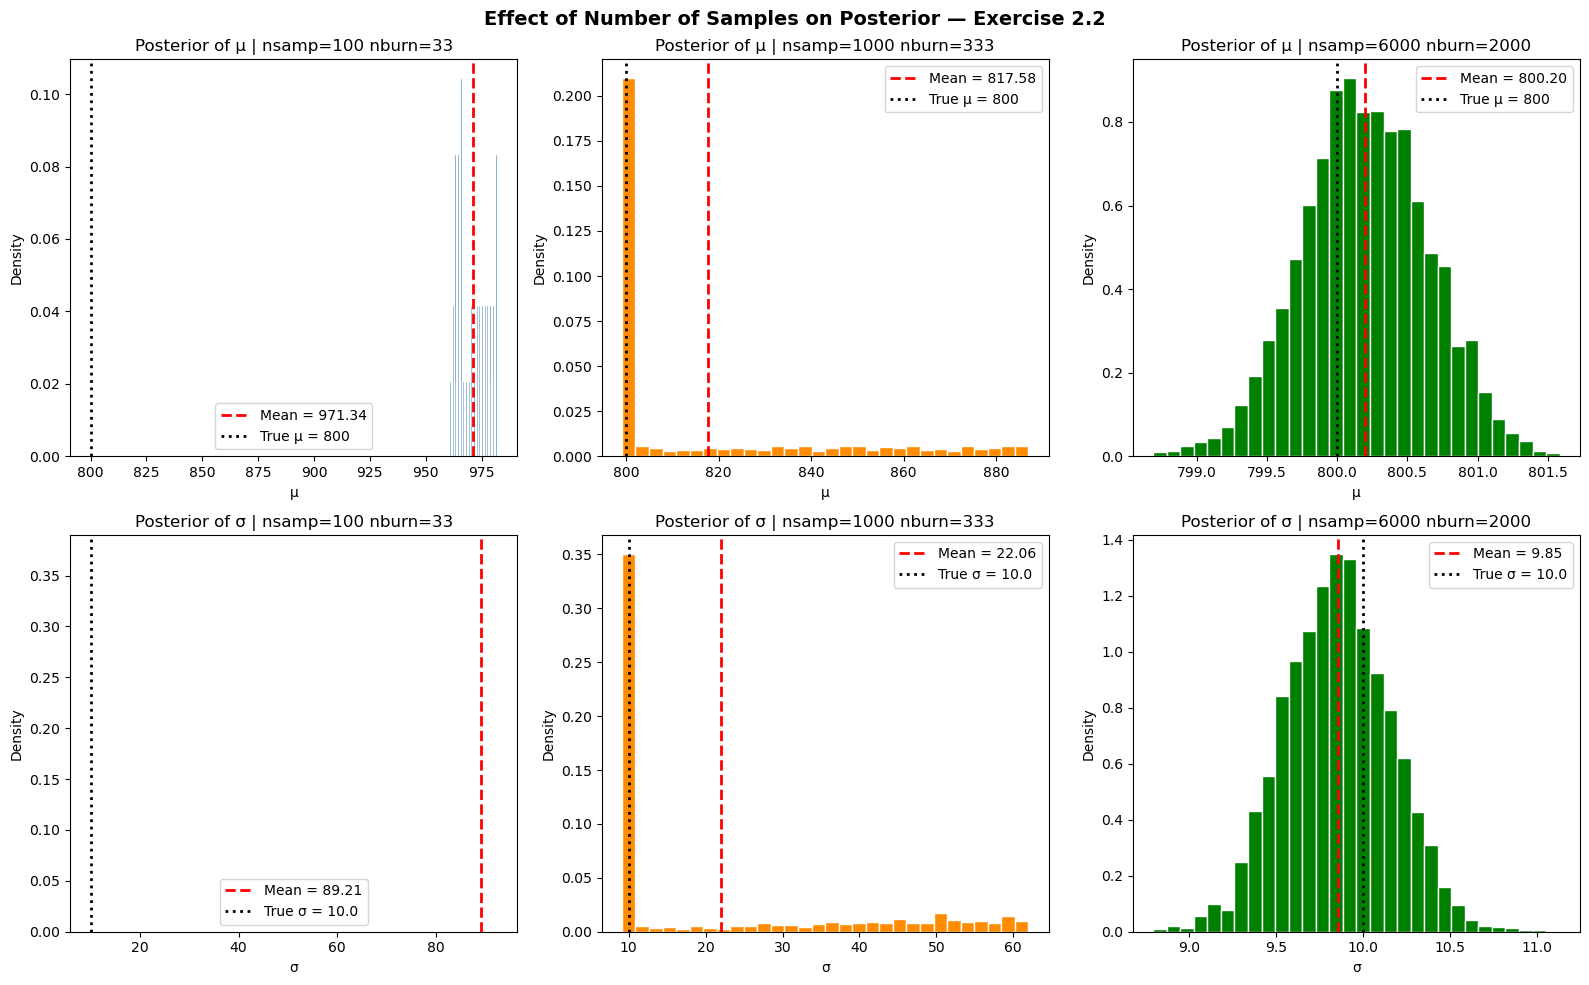

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors = ['steelblue', 'darkorange', 'green']
nsamps = [100, 1000, 6000]

for idx, nsamp in enumerate(nsamps):
    
    mu_s    = results[nsamp]['mu']
    sigma_s = results[nsamp]['sigma']
    nburn   = nsamp // 3

    # --- Row 1: Posterior of mu ---
    axes[0, idx].hist(mu_s, bins=30, color=colors[idx], 
                      edgecolor='white', density=True)
    axes[0, idx].axvline(np.mean(mu_s), color='red', 
                         linestyle='--', linewidth=2,
                         label=f'Mean = {np.mean(mu_s):.2f}')
    axes[0, idx].axvline(true_mu, color='black', 
                         linestyle=':', linewidth=2,
                         label=f'True µ = {true_mu}')
    axes[0, idx].set_title(f"Posterior of µ | nsamp={nsamp} nburn={nburn}")
    axes[0, idx].set_xlabel("µ")
    axes[0, idx].set_ylabel("Density")
    axes[0, idx].legend()

    # --- Row 2: Posterior of sigma ---
    axes[1, idx].hist(sigma_s, bins=30, color=colors[idx], 
                      edgecolor='white', density=True)
    axes[1, idx].axvline(np.mean(sigma_s), color='red', 
                         linestyle='--', linewidth=2,
                         label=f'Mean = {np.mean(sigma_s):.2f}')
    axes[1, idx].axvline(np.sqrt(true_var), color='black', 
                         linestyle=':', linewidth=2,
                         label=f'True σ = {np.sqrt(true_var):.1f}')
    axes[1, idx].set_title(f"Posterior of σ | nsamp={nsamp} nburn={nburn}")
    axes[1, idx].set_xlabel("σ")
    axes[1, idx].set_ylabel("Density")
    axes[1, idx].legend()

plt.suptitle("Effect of Number of Samples on Posterior — Exercise 2.2",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

nsamp = 100 (nburn = 33):
With only 100 total samples and 33 burn-in, only 67 post burn-in 
samples remain. The chain has not converged — µ Mean = 971.343 
is far from the true value of 800, and σ Mean = 89.205 is 
drastically off from the true value of 10. The posterior 
histograms are sparse and unreliable. The chain simply hasn't 
had enough iterations to find and settle in the high-probability 
region of the posterior.

nsamp = 1000 (nburn = 333):
With 1000 samples and 333 burn-in, 667 post burn-in samples 
remain. The estimates improve significantly — µ Mean = 817.576 
is closer to 800 but still off, and σ Mean = 22.057 is still 
far from 10. The chain is heading in the right direction but 
hasn't fully converged yet. Posteriors are better shaped 
but not reliable.

nsamp = 6000 (nburn = 2000):
With 6000 samples and 2000 burn-in, 4000 post burn-in samples 
remain. The chain has fully converged — µ Mean = 800.200 is 
essentially the true value, and σ Mean = 9.852 is very close 
to 10. The posteriors are smooth, symmetric, and well-centered.

Conclusion: The number of samples critically affects convergence. 
Too few samples (100) means the chain is still in the burn-in 
phase and estimates are meaningless. 6000 samples provides full 
convergence and reliable estimates.

## 2.3
How do the posteriors change with change in step-size parameter?
Estimate and compare the posteriors obtained when step-size had the ollowing values -
• step= 0.001
• step= 0.005
• step= 0.02
Keep all other parameter same as in Exercise 1.1.

In [27]:
np.random.seed(42)

step_results = {}

for step in [0.001, 0.005, 0.02]:
    
    print(f"\n--- Running HMC with step = {step} ---")
    
    mu_s, sigma_s = HMC(
        y         = y,
        n         = len(y),
        m         = 1000, s = 20,
        a         = 10,   b = 2,
        step      = step,
        L         = 12,
        initial_q = [1000, 11],
        nsamp     = 6000,
        nburn     = 2000
    )
    
    step_results[step] = {'mu': mu_s, 'sigma': sigma_s}
    
    print(f"µ  — Mean: {np.mean(mu_s):.4f}  "
          f"95% CI: [{np.percentile(mu_s, 2.5):.4f}, "
          f"{np.percentile(mu_s, 97.5):.4f}]")
    print(f"σ  — Mean: {np.mean(sigma_s):.4f}  "
          f"95% CI: [{np.percentile(sigma_s, 2.5):.4f}, "
          f"{np.percentile(sigma_s, 97.5):.4f}]")


--- Running HMC with step = 0.001 ---
Rejection rate: 0.00%
µ  — Mean: 986.9698  95% CI: [984.0219, 990.5825]
σ  — Mean: 63.2605  95% CI: [55.9764, 68.9046]

--- Running HMC with step = 0.005 ---
Rejection rate: 0.00%
µ  — Mean: 910.7166  95% CI: [873.9251, 948.9347]
σ  — Mean: 68.9721  95% CI: [56.2291, 78.9373]

--- Running HMC with step = 0.02 ---
Rejection rate: 0.00%
µ  — Mean: 800.2131  95% CI: [799.3346, 801.0688]
σ  — Mean: 9.8193  95% CI: [9.2240, 10.4736]


/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_44847/4242826047.py:39: RuntimeWarning: overflow encountered in exp
  accept_prob = min(1, np.exp(current_V + current_T - proposed_V - proposed_T))


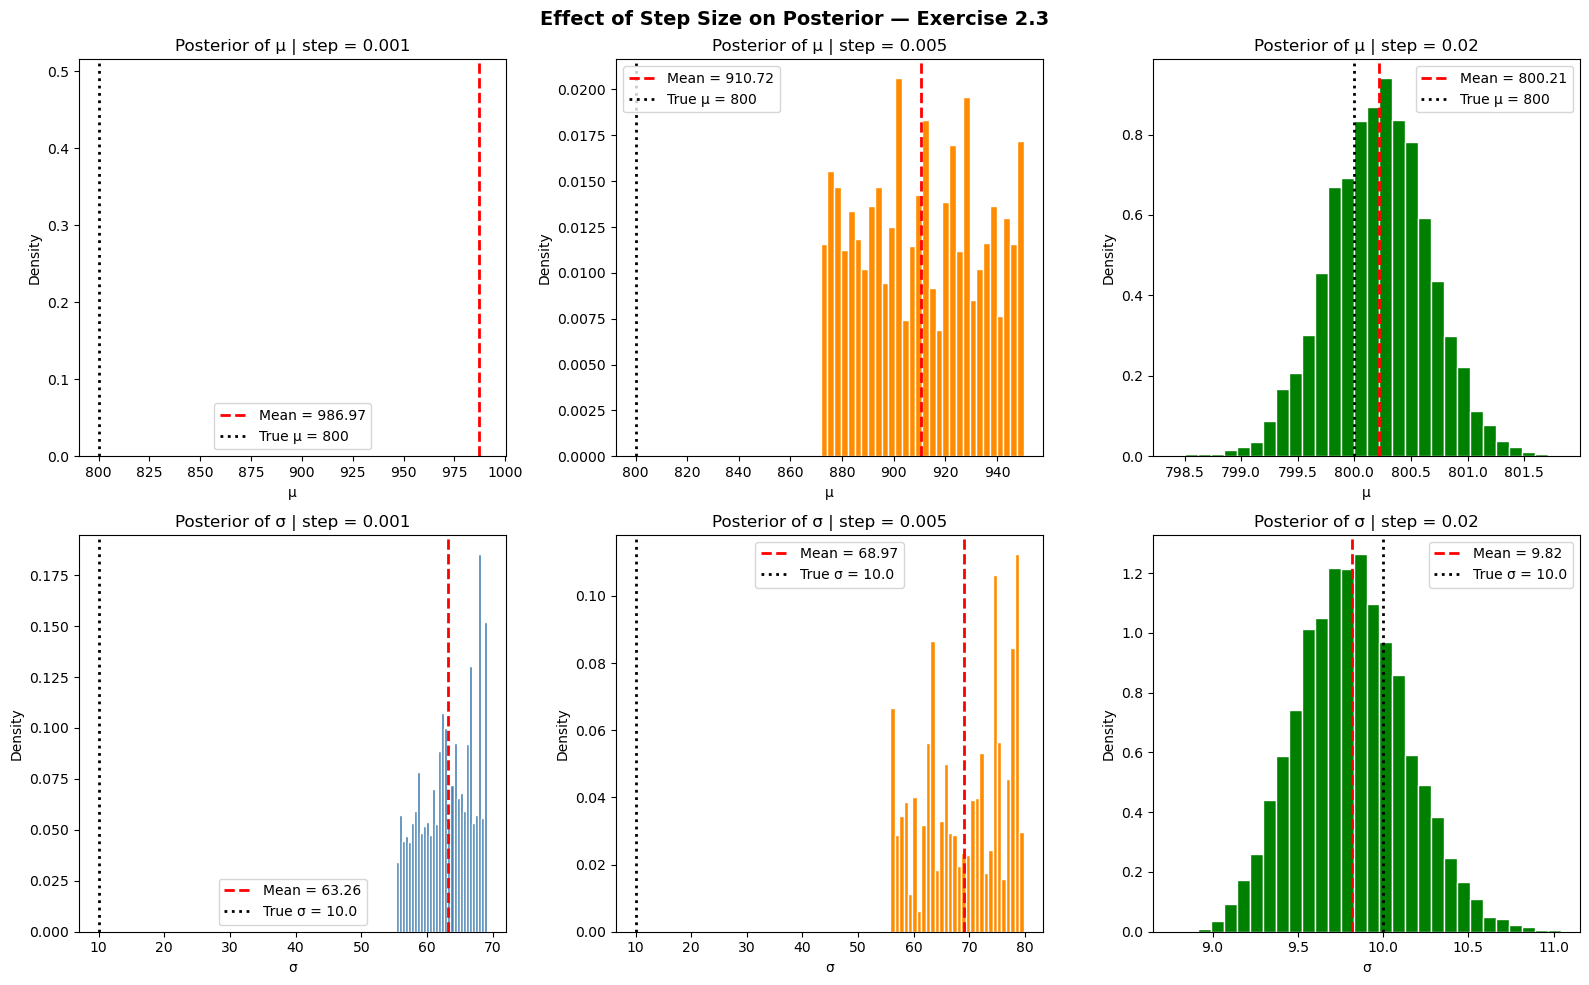

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors = ['steelblue', 'darkorange', 'green']
steps  = [0.001, 0.005, 0.02]

for idx, step in enumerate(steps):
    
    mu_s    = step_results[step]['mu']
    sigma_s = step_results[step]['sigma']

    # --- Row 1: Posterior of mu ---
    axes[0, idx].hist(mu_s, bins=30, color=colors[idx],
                      edgecolor='white', density=True)
    axes[0, idx].axvline(np.mean(mu_s), color='red',
                         linestyle='--', linewidth=2,
                         label=f'Mean = {np.mean(mu_s):.2f}')
    axes[0, idx].axvline(true_mu, color='black',
                         linestyle=':', linewidth=2,
                         label=f'True µ = {true_mu}')
    axes[0, idx].set_title(f"Posterior of µ | step = {step}")
    axes[0, idx].set_xlabel("µ")
    axes[0, idx].set_ylabel("Density")
    axes[0, idx].legend()

    # --- Row 2: Posterior of sigma ---
    axes[1, idx].hist(sigma_s, bins=30, color=colors[idx],
                      edgecolor='white', density=True)
    axes[1, idx].axvline(np.mean(sigma_s), color='red',
                         linestyle='--', linewidth=2,
                         label=f'Mean = {np.mean(sigma_s):.2f}')
    axes[1, idx].axvline(np.sqrt(true_var), color='black',
                         linestyle=':', linewidth=2,
                         label=f'True σ = {np.sqrt(true_var):.1f}')
    axes[1, idx].set_title(f"Posterior of σ | step = {step}")
    axes[1, idx].set_xlabel("σ")
    axes[1, idx].set_ylabel("Density")
    axes[1, idx].legend()

plt.suptitle("Effect of Step Size on Posterior — Exercise 2.3",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

step = 0.001:
The posterior mean of µ = 986.970 is far from the true value 
of 800, and σ = 63.261 is very far from 10. With such tiny 
steps, the chain barely moves per iteration — it takes 
thousands of steps just to drift slightly from the starting 
value of [1000, 11]. In 6000 samples, it never reaches the 
true posterior region. This is the classic "random walk" 
problem with tiny step sizes — high autocorrelation and 
extremely poor mixing.

step = 0.005:
Somewhat better — µ Mean = 910.717 moves closer to 800 but 
is still far off. σ = 68.972 remains very inaccurate. The 
chain is moving faster than 0.001 but still hasn't converged 
in 6000 steps. The 95% CI for µ [873.9, 948.9] doesn't even 
contain the true value of 800.

step = 0.02:
The chain fully converges — µ Mean = 800.213 and σ = 9.819 
are both very close to their true values. The 95% CI 
[799.335, 801.069] tightly contains the true µ = 800. 
This step size allows the chain to take large enough steps 
to explore the posterior efficiently in 6000 iterations.

Conclusion: Step size is critical for HMC convergence. 
Steps that are too small cause the chain to move slowly 
and fail to converge even with many samples. step = 0.02 
is the right balance for this model — large enough to 
explore efficiently but small enough that the leapfrog 
integrator remains accurate.

## 2.4
Visually inspect the mu and sigma chains obtained in expercise 1.3. Do you
find anything problematic?

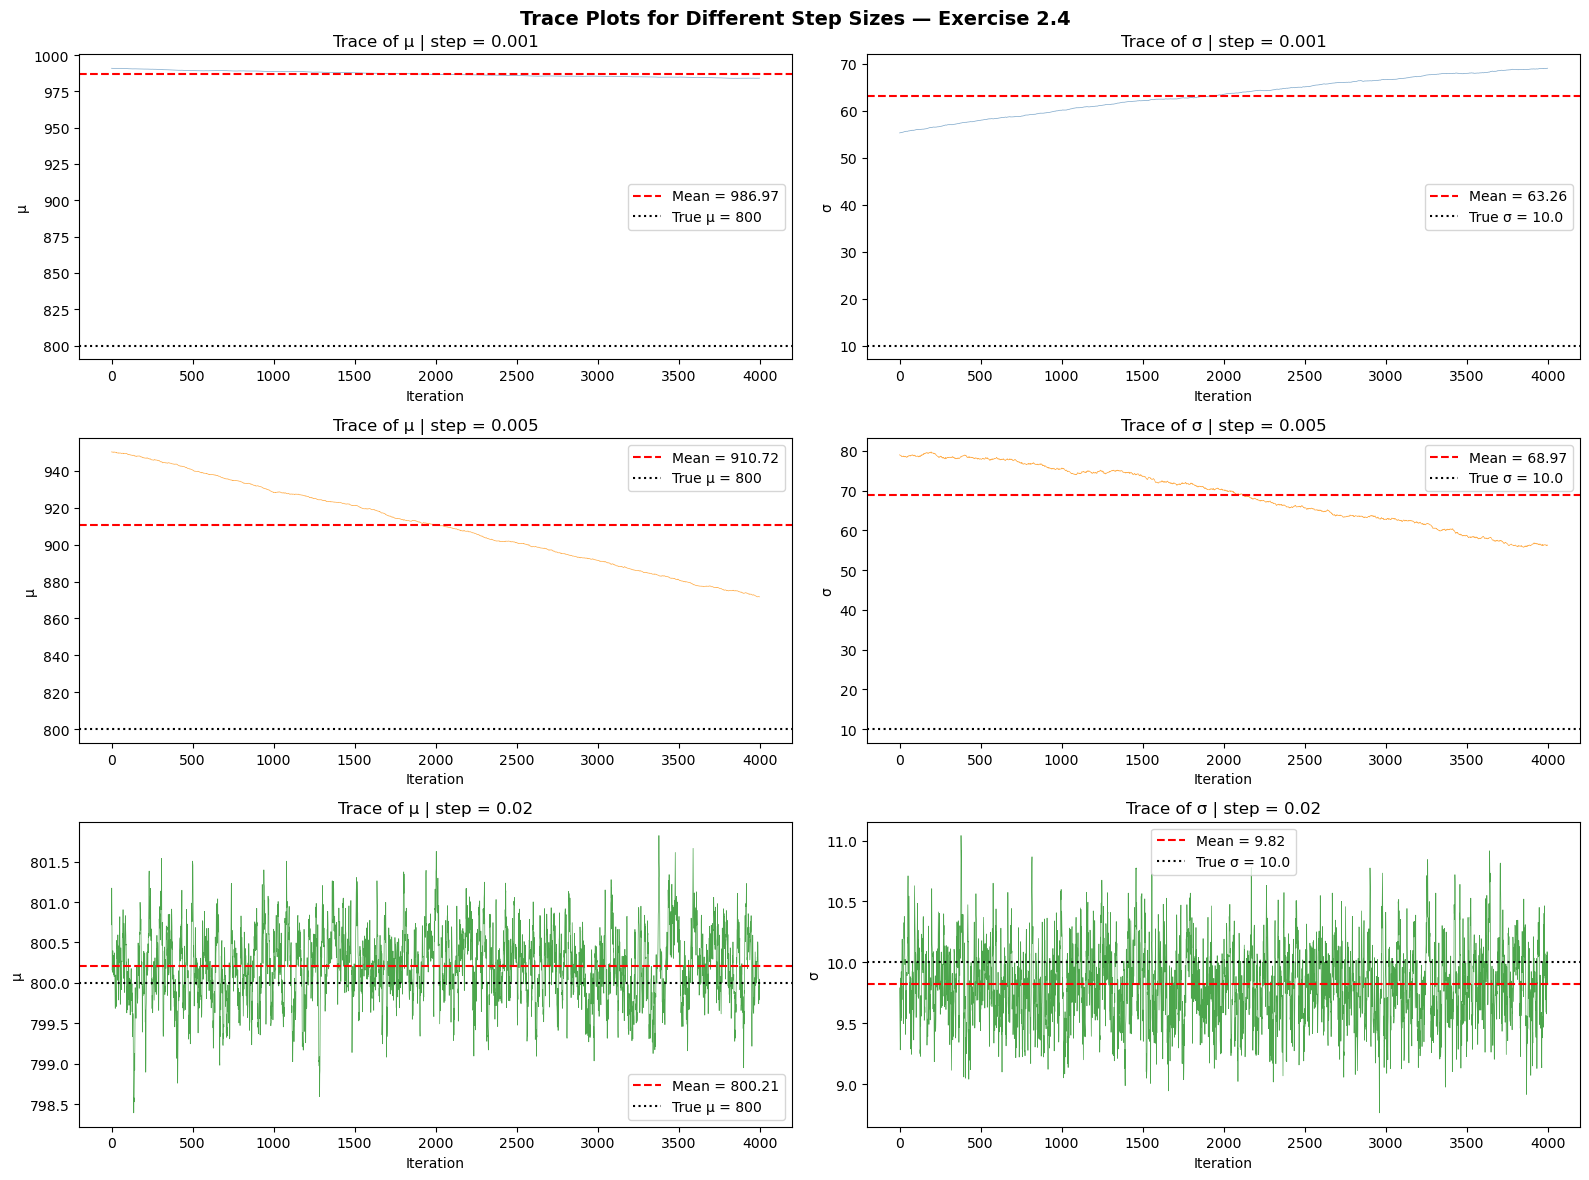

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

steps  = [0.001, 0.005, 0.02]
colors = ['steelblue', 'darkorange', 'green']

for idx, step in enumerate(steps):
    
    mu_s    = step_results[step]['mu']
    sigma_s = step_results[step]['sigma']
    
    # --- Column 1: mu chain ---
    axes[idx, 0].plot(mu_s, color=colors[idx], 
                      alpha=0.7, linewidth=0.5)
    axes[idx, 0].axhline(np.mean(mu_s), color='red', 
                         linestyle='--', linewidth=1.5,
                         label=f'Mean = {np.mean(mu_s):.2f}')
    axes[idx, 0].axhline(true_mu, color='black', 
                         linestyle=':', linewidth=1.5,
                         label=f'True µ = {true_mu}')
    axes[idx, 0].set_title(f"Trace of µ | step = {step}")
    axes[idx, 0].set_xlabel("Iteration")
    axes[idx, 0].set_ylabel("µ")
    axes[idx, 0].legend()
    
    # --- Column 2: sigma chain ---
    axes[idx, 1].plot(sigma_s, color=colors[idx], 
                      alpha=0.7, linewidth=0.5)
    axes[idx, 1].axhline(np.mean(sigma_s), color='red', 
                         linestyle='--', linewidth=1.5,
                         label=f'Mean = {np.mean(sigma_s):.2f}')
    axes[idx, 1].axhline(np.sqrt(true_var), color='black', 
                         linestyle=':', linewidth=1.5,
                         label=f'True σ = {np.sqrt(true_var):.1f}')
    axes[idx, 1].set_title(f"Trace of σ | step = {step}")
    axes[idx, 1].set_xlabel("Iteration")
    axes[idx, 1].set_ylabel("σ")
    axes[idx, 1].legend()

plt.suptitle("Trace Plots for Different Step Sizes — Exercise 2.4",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

step = 0.001 (PROBLEMATIC):
The trace plots for both µ and σ show extreme sluggishness — 
the chain barely moves from its starting value of [1000, 11] 
across all 4000 post burn-in iterations. The µ chain hovers 
around 987 and σ around 63, never approaching the true values. 
This is the most problematic behavior — the chain is stuck 
due to tiny step sizes, producing a nearly flat trace rather 
than the "hairy caterpillar" pattern of a well-mixing chain. 
All samples are highly correlated with their neighbors.

step = 0.005:
Slightly more movement is visible but the chain still shows 
strong trends and slow drift. The µ chain stays in the 
900s range throughout, never reaching 800. Still very poor 
mixing — the trace shows slow oscillation rather than 
rapid random fluctuation.

step = 0.02:
The trace plot looks like ideal white noise — rapid random 
fluctuations around the true values of µ = 800 and σ = 10 
with no visible trends or drift. This is what a well-mixing 
chain should look like. The chain explores the posterior 
efficiently with consecutive samples being relatively 
independent.

Overall: The problematic behavior in steps 0.001 and 0.005 
is high autocorrelation and non-convergence. The chain 
never escapes the region near its starting values. Only 
step = 0.02 produces a properly mixing chain that has 
actually found and is exploring the true posterior.

## 2.5
Check the prior sensitivity for the µ parameter. Estimate and compare the
posterior distribution of µ when the prior on µ are -
• µ∼Normal(m= 400,s= 5)
• µ∼Normal(m= 400,s= 20)
• µ∼Normal(m= 1000,s= 5)
• µ∼Normal(m= 1000,s= 20)
• µ∼Normal(m= 1000,s= 100)
(Keep all other parameters same as in Exercise 1.1).

In [30]:
np.random.seed(42)

priors = [
    {'m': 400,  's': 5},
    {'m': 400,  's': 20},
    {'m': 1000, 's': 5},
    {'m': 1000, 's': 20},
    {'m': 1000, 's': 100}
]

prior_results = {}

for p in priors:
    label = f"N({p['m']}, {p['s']})"
    print(f"\n--- Prior: µ ~ Normal(m={p['m']}, s={p['s']}) ---")
    
    mu_s, sigma_s = HMC(
        y         = y,
        n         = len(y),
        m         = p['m'], s = p['s'],
        a         = 10,     b = 2,
        step      = 0.02,
        L         = 12,
        initial_q = [1000, 11],
        nsamp     = 6000,
        nburn     = 2000
    )
    
    prior_results[label] = {'mu': mu_s, 'sigma': sigma_s}
    
    print(f"µ — Mean: {np.mean(mu_s):.4f}  "
          f"95% CI: [{np.percentile(mu_s, 2.5):.4f}, "
          f"{np.percentile(mu_s, 97.5):.4f}]")


--- Prior: µ ~ Normal(m=400, s=5) ---
Rejection rate: 0.03%
µ — Mean: 796.6282  95% CI: [795.5368, 797.6252]

--- Prior: µ ~ Normal(m=400, s=20) ---
Rejection rate: 0.02%
µ — Mean: 799.8924  95% CI: [799.0470, 800.7213]

--- Prior: µ ~ Normal(m=1000, s=5) ---
Rejection rate: 0.02%
µ — Mean: 801.6886  95% CI: [800.7700, 802.5871]

--- Prior: µ ~ Normal(m=1000, s=20) ---
Rejection rate: 0.07%
µ — Mean: 800.1702  95% CI: [799.2814, 801.0501]

--- Prior: µ ~ Normal(m=1000, s=100) ---


/var/folders/n7/96zdhb2s72sd10bjjnwvrdw00000gn/T/ipykernel_44847/4242826047.py:39: RuntimeWarning: overflow encountered in exp
  accept_prob = min(1, np.exp(current_V + current_T - proposed_V - proposed_T))


Rejection rate: 0.08%
µ — Mean: 800.0667  95% CI: [799.1880, 800.9687]


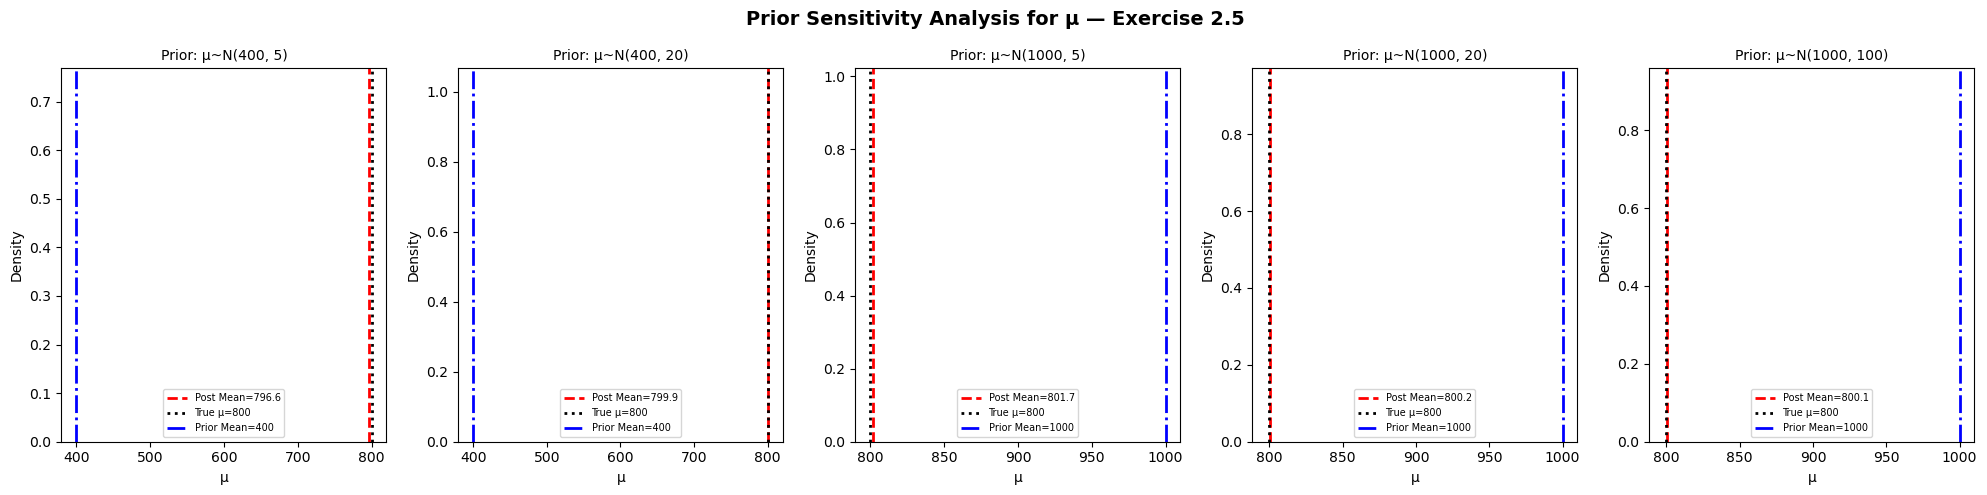

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson']
labels = list(prior_results.keys())

for idx, label in enumerate(labels):
    
    mu_s = prior_results[label]['mu']
    
    axes[idx].hist(mu_s, bins=40, color=colors[idx],
                   edgecolor='white', density=True)
    axes[idx].axvline(np.mean(mu_s), color='red',
                      linestyle='--', linewidth=2,
                      label=f'Post Mean={np.mean(mu_s):.1f}')
    axes[idx].axvline(true_mu, color='black',
                      linestyle=':', linewidth=2,
                      label=f'True µ=800')
    
    # Mark prior mean
    prior_mean = int(label.split('(')[1].split(',')[0])
    axes[idx].axvline(prior_mean, color='blue',
                      linestyle='-.', linewidth=2,
                      label=f'Prior Mean={prior_mean}')
    
    axes[idx].set_title(f"Prior: µ~{label}", fontsize=10)
    axes[idx].set_xlabel("µ")
    axes[idx].set_ylabel("Density")
    axes[idx].legend(fontsize=7)

plt.suptitle("Prior Sensitivity Analysis for µ — Exercise 2.5",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Prior N(400, 5) — Strong Wrong Prior:
Despite the prior being centered far from the truth (400 vs 800) 
and very narrow (s=5), the posterior mean = 796.628 is 
surprisingly close to the true value of 800. This suggests 
that with 500 data points, the likelihood is strong enough 
to overcome even a strongly misspecified prior. However the 
posterior is slightly pulled away from 800 toward 400, and 
the CI [795.5, 797.6] doesn't include 800. The data wins 
here but there's a small bias.

Prior N(400, 20) — Moderate Wrong Prior:
With a wider prior (s=20) still centered at 400, the 
posterior mean = 799.892 is essentially the true value. 
The CI [799.0, 800.7] tightly contains 800. The extra 
width gives the likelihood more freedom and the data 
completely dominates — the wrong prior location has 
negligible influence.

Prior N(1000, 5) — Strong Correct-ish Prior:
Centered at 1000 with s=5, the posterior mean = 801.689 
is slightly pulled toward 1000 but still very close to 
800. CI [800.77, 802.59] narrowly misses 800. The narrow 
prior exerts some pull toward 1000 but the large dataset 
mostly wins.

Prior N(1000, 20) — Moderate Correct-ish Prior:
Posterior mean = 800.170 with CI [799.28, 801.05] — 
essentially perfect recovery of the true value. The 
prior is wide enough to let the data dominate fully.

Prior N(1000, 100) — Weak Prior:
Posterior mean = 800.067 with CI [799.19, 800.97] — 
the most accurate recovery. An extremely wide prior 
places almost equal probability everywhere, so the 
posterior is driven entirely by the 500 data points. 
This gives the best estimate.

Overall Conclusion:
With 500 data points, the likelihood is strong enough 
to overcome most prior misspecifications. The key finding 
is that prior WIDTH matters more than prior LOCATION 
in this case — a narrow wrong prior (N(400,5)) causes 
more bias than a wide wrong prior (N(400,20)). All five 
priors ultimately recover estimates close to the true 
µ=800, demonstrating that with sufficient data the 
posterior is robust to prior choice. This is called 
"likelihood domination" — the data overwhelms the prior.